# Ultimate comparisons
5s Deep vs 5s handextracted <br>
5s Deep vs 1s Deep <br>
Region Selection starting from 1s vs 3s <br>
Important regions vs Cohen vs All regions <br>
Single modality vs fusion (EEG+MEG) (To be done)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    del lolliplot
except NameError:
    pass

def lolliplot(he, de, me=None, annotate=None, legendlabels=None):
    """
    takes 3 arrays of performances and plot the performances per subject 
    as a horizontal lollipop plot, SORTED by de
    
    """

    he, de = np.array(he), np.array(de)
    me = np.array(me) if me is not None else None
    ord_ = de.argsort()


    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_yticks(range(len(ord_)))
    ax.set_yticklabels(ord_)

    for y,i in enumerate(ord_):
        xs = [he[i], de[i]] + ([me[i]] if me is not None else [])
        ax.plot([min(xs), max(xs)], [y,y], color="grey", lw=0.8, alpha=0.7)

    ax.scatter(he[ord_], range(len(ord_)), color="red",   alpha=0.8, zorder=10, label=None if legendlabels is None else legendlabels[0])
    ax.scatter(de[ord_], range(len(ord_)), color="green", alpha=0.8, zorder=10, label=None if legendlabels is None else legendlabels[1])
    if me is not None:
        ax.scatter(me[ord_], range(len(ord_)), color="orange", alpha=0.8, zorder=10, label=None if legendlabels is None else legendlabels[2])

    if annotate:
        for y,i in enumerate(ord_):
            if i in annotate:
                if me is None:
                    # original 2-series behavior
                    vals = {"he":he[i], "de":de[i]}
                    sorted_vals = sorted(vals.items(), key=lambda x: x[1])
                    (_, worst),(_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right", va="center", fontsize=8)
                    ax.text(best+0.005, y, f"{best:.2f}", ha="left",  va="center", fontsize=8)
                else:
                    vals = {"he":he[i], "de":de[i], "me":me[i]}
                    sorted_vals = sorted(vals.items(), key=lambda x: x[1])
                    (_, worst), (_, mid), (_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right",  va="center", fontsize=8)
                    ax.text(best+0.004,  y, f"{best:.2f}",  ha="left",   va="center", fontsize=8)
                    ax.text(mid, y+0.2, f"{mid:.2f}",     ha="center", va="bottom", fontsize=8)

    lims = ax.get_xlim()
    ax.hlines(range(len(ord_)), lims[0], lims[1], color="grey", lw=0.6, alpha=0.3,
              linestyle=(-10,(40,10)))
    ax.set_xlim(lims[0]-0.01, lims[1]+0.01)

    if legendlabels:
        plt.legend()

    return fig, ax



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap

# ultimate performances (deep, EEG+MEG, cohen selection from 3s)
acc_mean_deep_region_selection_from_3s = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s.pkl").Accuracy.apply(np.mean).values)

# region selection from 1s
acc_mean_deep_1s = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN.pkl").Accuracy.apply(np.mean).values)

# region selection from 1s
acc_mean_handextracted_5s = [.97,.75,.91,.75,.83,.97,.86,.81,.85,.88,.93,.82,.9,.75,.89,.77,.88,.76,.76,.78] 

# region selection from 3s
acc_mean_handextracted_5s_region_selection_from_3s = list(pd.read_pickle("../Results/BCI_Performances/All_subjects_BCI_Performances_ultimate_region_selection_from_3s.pkl").Accuracy.apply(np.mean).values)

# region selection from 1s
acc_mean_deep_5s = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_DNN_Classification_5s_windows.pkl").Accuracy.apply(np.mean).values)

# EEG+MEG
acc_mean_deep_all_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_all_regions.pkl").Accuracy.apply(np.mean).values)
acc_mean_deep_important_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_important_regions.pkl").Accuracy.apply(np.mean).values)

# Signle modality classification, region selection (EEG U MEG) from 3s
acc_mean_deep_EEG = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_EEG.pkl").Accuracy.apply(np.mean).values)
acc_mean_deep_MEG = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_MEG.pkl").Accuracy.apply(np.mean).values)


# Confronto 1: Deep EEG (MEG) cohen single modality vs important
acc_deep_EEG_important_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_EEG_Important_regions.pkl").Accuracy.apply(np.mean).values)
acc_deep_MEG_important_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_MEG_Important_regions.pkl").Accuracy.apply(np.mean).values)

acc_deep_EEG_Only_EEG_selected_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_EEG_only_EEG_reg_selection.pkl").Accuracy.apply(np.mean).values)
acc_deep_MEG_Only_MEG_selected_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_MEG_only_MEG_reg_selection.pkl").Accuracy.apply(np.mean).values)

# Lemma (Forse) Confronto 2 EEG vs MEG (cohen single modality? regioni differenti...)
# Confronto 2 EEG+MEG cohen (single modality?) vs EEG (MEG)
acc_deep_EEG_MEG_selection_only_EEG = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_EEG+MEG_only_EEG_reg_selection.pkl").Accuracy.apply(np.mean).values)

# Confronto 3 Deep EEG+MEG vs PowerSpectra EEG+MEG
acc_mean_deep_region_selection_from_3s, # uu,acc_mean_handextracted_1s_region_selection_from_3s


# ultimate handextracted (PowerSpectra, EEG+MEG, cohen selection from 3s)
uu = pd.read_pickle("../Results/BCI_Performances/All_subjects_BCI_Performances_ultimate_region_selection_from_3s_windows_1s.pkl").Accuracy
conta = 0
acc_mean_handextracted_1s_region_selection_from_3s = []
for acc_subj in uu:
    acc_mean_handextracted_1s_region_selection_from_3s.append(0)
    for fold in acc_subj:
        for wind in range(7):
            conta +=1
            acc_mean_handextracted_1s_region_selection_from_3s[-1] += fold[f"win_{wind}"]/35

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from scipy import stats
try:
    del lollipop_with_kde
except:
    pass
def lollipop_with_kde(he, de, me=None, annotate=None, legendlabels=None, showdensity=True, sort=True):
    """
    Lollipop plot + distribution (KDE) strip on top (same x-axis).

    he, de, me: arrays of performances
    annotate: list of subject indices to annotate
    legendlabels: list like ["HE", "DE", "ME"]
    """

    he, de = np.array(he), np.array(de)
    me = np.array(me) if me is not None else None

    ord_ = de.argsort() if sort else np.arange(len(de))

    fig, ax = plt.subplots(figsize=(7,5))

    # =========================
    # LOLLIPOP (your original)
    # =========================
    ax.set_yticks(range(len(ord_)))
    ax.set_yticklabels(ord_)

    for y, i in enumerate(ord_):
        xs = [he[i], de[i]] + ([me[i]] if me is not None else [])
        ax.plot([min(xs), max(xs)], [y, y], color="grey", lw=0.8, alpha=0.7)

    ax.scatter(he[ord_], range(len(ord_)), color="red",   alpha=0.8,
               zorder=10, label=None if legendlabels is None else legendlabels[0])
    ax.scatter(de[ord_], range(len(ord_)), color="green", alpha=0.8,
               zorder=10, label=None if legendlabels is None else legendlabels[1])

    if me is not None:
        ax.scatter(me[ord_], range(len(ord_)), color="orange", alpha=0.8,
                   zorder=10, label=None if legendlabels is None else legendlabels[2])

    # annotations (unchanged)
    if annotate:
        for y, i in enumerate(ord_):
            if i in annotate:
                vals = {"he":he[i], "de":de[i]}
                if me is not None:
                    vals["me"] = me[i]

                sorted_vals = sorted(vals.items(), key=lambda x: x[1])

                if me is None:
                    (_, worst), (_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right", va="center", fontsize=8)
                    ax.text(best+0.005, y, f"{best:.2f}", ha="left",  va="center", fontsize=8)
                else:
                    (_, worst), (_, mid), (_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right", va="center", fontsize=8)
                    ax.text(best+0.004,  y, f"{best:.2f}",  ha="left",  va="center", fontsize=8)
                    ax.text(mid, y+0.2, f"{mid:.2f}", ha="center", va="bottom", fontsize=8)

    lims = ax.get_xlim()
    ax.hlines(range(len(ord_)), lims[0], lims[1],
              color="grey", lw=0.6, alpha=0.3,
              linestyle=(-10,(40,10)))
    ax.set_xlim(lims[0]-0.01, lims[1]+0.01)

    if legendlabels:
        ax.legend()

    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Subjects")

    # =========================
    # TOP DISTRIBUTION (KDE)
    # =========================
    if showdensity:
        ax_top = inset_axes(
            ax,
            width="100%",
            height="100%",
            loc="upper center",
            bbox_to_anchor=(0, 1, 1, 0.2),
            bbox_transform=ax.transAxes,
            borderpad=0
        )

        data = [he, de] + ([me] if me is not None else [])
        colors = ["red", "green", "orange"][:len(data)]

        for arr, c in zip(data, colors):
            sns.kdeplot(
                arr,
                ax=ax_top,
                color=c,
                fill=True,
                alpha=0.25,
                linewidth=1
            )
            ax_top.axvline(np.mean(arr), color=c, linestyle="--", linewidth=1.2)
            ax_top.axvline(np.median(arr), color=c, linestyle="-", linewidth=1.2)

        # align with main axis
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks([])
        ax_top.set_yticks([])

        # clean look
        for spine in ax_top.spines.values():
            spine.set_visible(False)

    # plt.tight_layout()
    return fig, ax

## Confronto 1 - EEG(MEG) important vs cohen single modality

1

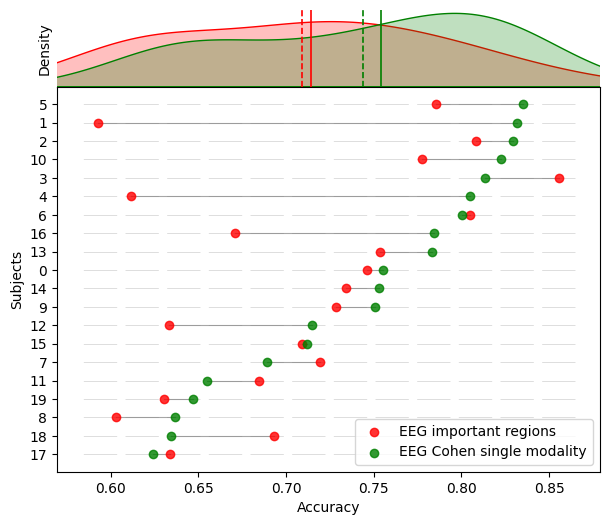

In [ ]:
lollipop_with_kde(acc_deep_EEG_important_regions, acc_deep_EEG_Only_EEG_selected_regions,  legendlabels=["EEG important regions", "EEG Cohen single modality"])
acc_deep_MEG_important_regions, acc_deep_MEG_Only_MEG_selected_regions
acc_deep_EEG_important_regions, acc_deep_EEG_Only_EEG_selected_regions
1

In [ ]:
stat, p_value = stats.wilcoxon(acc_deep_EEG_important_regions, acc_deep_EEG_Only_EEG_selected_regions, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG cohen different from EEG important: stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_EEG_important_regions)-np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")

stat, p_value = stats.wilcoxon(acc_deep_MEG_important_regions, acc_deep_MEG_Only_MEG_selected_regions, alternative="two-sided", zero_method="wilcox")
print(f"Test MEG cohen different from MEG important: stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_MEG_important_regions)-np.mean(acc_deep_MEG_Only_MEG_selected_regions):.4f}")

Test EEG cohen different from EEG important: stat=56.0000, p=0.0696, mean difference=-0.0350
Test MEG cohen different from MEG important: stat=31.0000, p=0.0042, mean difference=-0.0462


## Confronto 2 - EEG(MEG) vs EEG+MEG (cohen 1 modality or cohen 2 modality?)

### Confronto 2 - Lemma EEG vs MEG (1 or 2 modality selection?)
Risalto, per alcuni subject MEG è meglio di EEG (debole) <br> 
Altri è confrontabile, potrebbero avere info complementari <br>
forse conviene fare con selection su single modality, e mostrare di confronto anche le double modality <br>
poi presentare direttamente EEG U MEG per confronto EEG vs EEG+MEG <br>
Prova a vedere test statistici su single subjects

Test EEG different MEG (Cohen single): stat=42.0000, p=0.0172, mean difference=-0.0618
MEG:0.6820 EEG: 0.7438
Where MEG > EEG (array([ 2,  5,  6,  7, 10, 12, 18, 19]),)


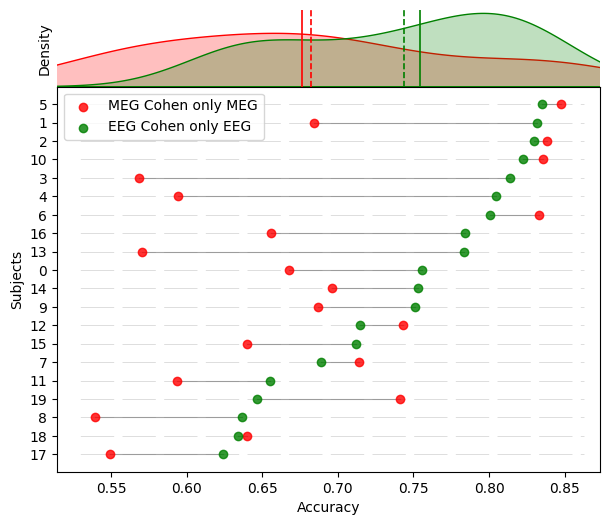

In [20]:
lollipop_with_kde(acc_deep_MEG_Only_MEG_selected_regions, acc_deep_EEG_Only_EEG_selected_regions,  legendlabels=["MEG Cohen only MEG", "EEG Cohen only EEG"])
stat, p_value = stats.wilcoxon(acc_deep_MEG_Only_MEG_selected_regions, acc_deep_EEG_Only_EEG_selected_regions, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG different MEG (Cohen single): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_MEG_Only_MEG_selected_regions)-np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")
print(f"MEG:{np.mean(acc_deep_MEG_Only_MEG_selected_regions):.4f} EEG: {np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")
print(f"Where MEG > EEG {np.where(np.array(acc_deep_MEG_Only_MEG_selected_regions) > np.array(acc_deep_EEG_Only_EEG_selected_regions))}")

Test EEG different MEG (Cohen EEG U MEG): stat=26.0000, p=0.0020, mean difference=-0.0800
MEG:0.6878 EEG: 0.7678
Where MEG > EEG (array([ 2,  5,  6, 12, 19]),)


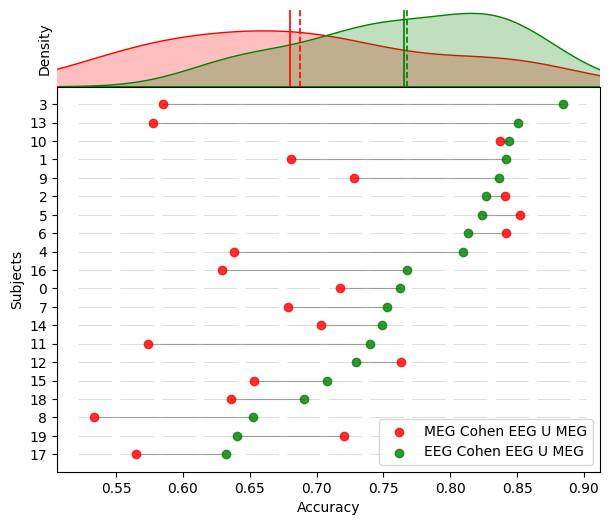

In [21]:
lollipop_with_kde(acc_mean_deep_MEG, acc_mean_deep_EEG,  legendlabels=["MEG Cohen EEG U MEG", "EEG Cohen EEG U MEG"])
stat, p_value = stats.wilcoxon(acc_mean_deep_MEG, acc_mean_deep_EEG, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG different MEG (Cohen EEG U MEG): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_mean_deep_MEG)-np.mean(acc_mean_deep_EEG):.4f}")
print(f"MEG:{np.mean(acc_mean_deep_MEG):.4f} EEG: {np.mean(acc_mean_deep_EEG):.4f}")
print(f"Where MEG > EEG {np.where(np.array(acc_mean_deep_MEG) > np.array(acc_mean_deep_EEG))}")


### Confronto 2 EEG(MEG) vs EEG+MEG

Test EEG+MEG different EEG (Cohen multiple): stat=52.0000, p=0.1446, mean difference=-0.0119
EEG:0.7678 EEG+MEG: 0.7797


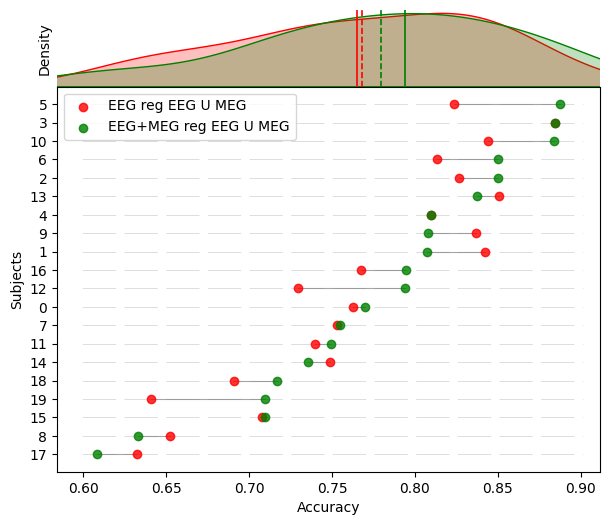

In [3]:
# Region Selection Cohen EEG U MEG
fig,ax = lollipop_with_kde(acc_mean_deep_EEG, acc_mean_deep_region_selection_from_3s,  legendlabels=["EEG reg EEG U MEG", "EEG+MEG reg EEG U MEG"])
stat, p_value = stats.wilcoxon(acc_mean_deep_EEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG+MEG different EEG (Cohen multiple): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_mean_deep_EEG)-np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
print(f"EEG:{np.mean(acc_mean_deep_EEG):.4f} EEG+MEG: {np.mean(acc_mean_deep_region_selection_from_3s):.4f}")


Test EEG+MEG different EEG (Cohen only EEG): stat=90.0000, p=0.5958, mean difference=-0.0056
EEG:0.7438 EEG+MEG: 0.7494


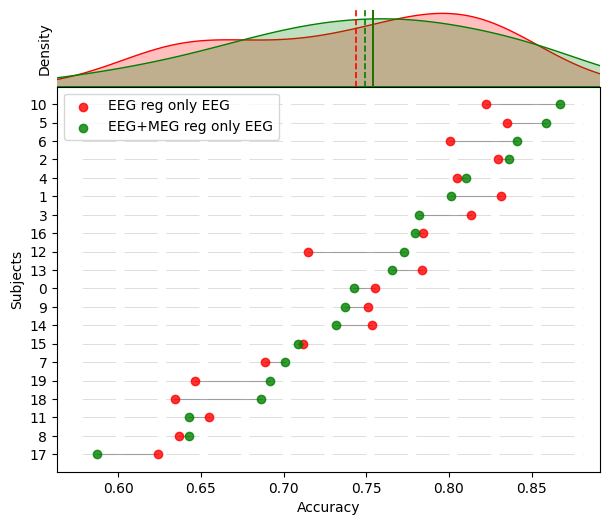

In [ ]:
# Region Selection Cohen only EEG  (DA NON MOSTRARE)

fig,ax = lollipop_with_kde(acc_deep_EEG_Only_EEG_selected_regions, acc_deep_EEG_MEG_selection_only_EEG,  legendlabels=["EEG reg only EEG", "EEG+MEG reg only EEG"])
stat, p_value = stats.wilcoxon(acc_deep_EEG_Only_EEG_selected_regions, acc_deep_EEG_MEG_selection_only_EEG, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG+MEG different EEG (Cohen only EEG): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_EEG_Only_EEG_selected_regions)-np.mean(acc_deep_EEG_MEG_selection_only_EEG):.4f}")
print(f"EEG:{np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f} EEG+MEG: {np.mean(acc_deep_EEG_MEG_selection_only_EEG):.4f}")

### Confronto 2 EEG+MEG vs best between EEG,MEG

Test best between EEG and MEG different from EEG+MEG: stat=75.0000, p=0.6475


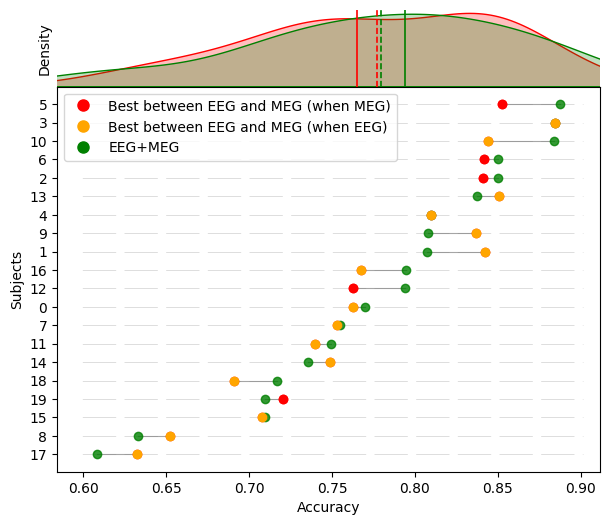

In [9]:

import matplotlib.lines as mlines

acc_mean_best_between_EEG_MEG = np.maximum(acc_mean_deep_EEG, acc_mean_deep_MEG)

fig,ax = lollipop_with_kde(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s)

ordine_EEEGplusMEG = np.argsort(acc_mean_deep_region_selection_from_3s)

best_MEG = []
best_EEG = []
for i in range(len(acc_mean_deep_MEG)):
    if acc_mean_deep_MEG[i] > acc_mean_deep_EEG[i]:
        best_MEG.append((acc_mean_deep_MEG[i],np.where(ordine_EEEGplusMEG==i)[0][0]))

for i in range(len(acc_mean_deep_EEG)):
    if acc_mean_deep_EEG[i] >= acc_mean_deep_MEG[i]:
        best_EEG.append((acc_mean_deep_EEG[i],np.where(ordine_EEEGplusMEG==i)[0][0]))

ax.scatter([i[0] for i in best_EEG], [i[1] for i in best_EEG], zorder=20,color="orange")
ax.scatter([i[0] for i in best_MEG], [i[1] for i in best_MEG], zorder=20,color="red")

red_dot = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                        markersize=8, label='Best between EEG and MEG (when MEG)')
orange_dot = mlines.Line2D([], [], color='orange', marker='o', linestyle='None',
                        markersize=8, label='Best between EEG and MEG (when EEG)'
                        )
green_dot = mlines.Line2D([], [], color='green', marker='o', linestyle='None',
                        markersize=8, label='EEG+MEG'
                        )
ax.legend(handles=[red_dot, orange_dot, green_dot])
stat, p_value = stats.wilcoxon(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test best between EEG and MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

In [ ]:
from scipy.stats import wasserstein_distance

from scipy.stats import ks_2samp
ks_2samp(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s)
# statistica 0.15 è uguale a statistica di distribuzione uniforme [0,1] e [0.15,1]

0.014378599685488222


KstestResult(statistic=np.float64(0.15), pvalue=np.float64(0.9831368772656193), statistic_location=np.float64(0.7676470588235293), statistic_sign=np.int8(1))

<Axes: ylabel='Density'>

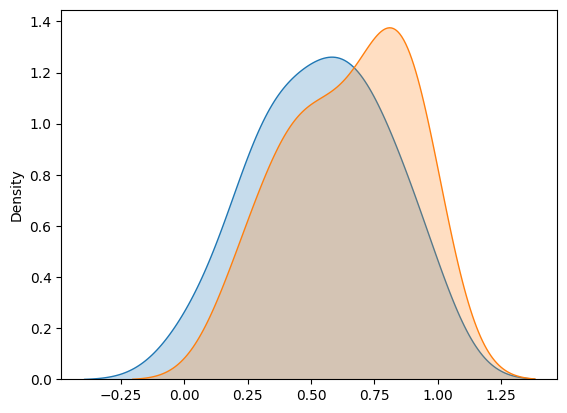

In [170]:
u1=np.random.uniform(0,1,20)
u2=np.random.uniform(0.15,1,20)
sns.kdeplot(u1,fill=True,alpha=0.25,linewidth=1)
sns.kdeplot(u2,fill=True,alpha=0.25,linewidth=1)

In [171]:
ks_2samp(u1,u2)

KstestResult(statistic=np.float64(0.25), pvalue=np.float64(0.571336004933722), statistic_location=np.float64(0.7399675931427356), statistic_sign=np.int8(1))

In [107]:
stats.wilcoxon(u1, u2, alternative="two-sided", zero_method="wilcox")

WilcoxonResult(statistic=np.float64(240446.0), pvalue=np.float64(0.2831950514540382))

## Confronto 3 - EEG+MEG - Deep vs HandExtracted

Test Deep different from HandExtracted: stat=1.0000, p=0.0000, mean difference=-0.0412


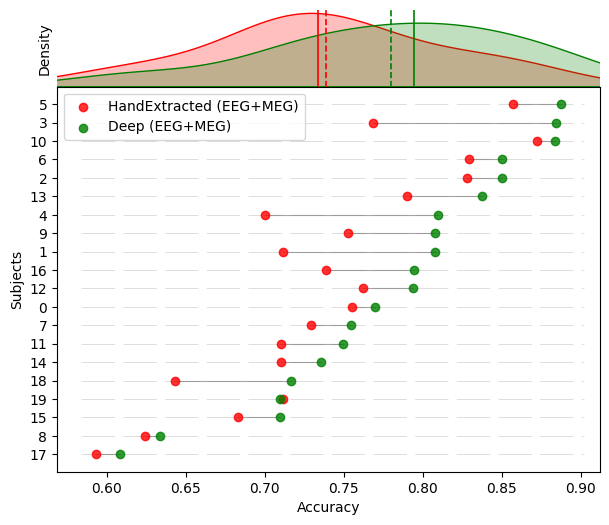

In [10]:
acc_mean_deep_region_selection_from_3s
acc_mean_handextracted_1s_region_selection_from_3s

lollipop_with_kde(acc_mean_handextracted_1s_region_selection_from_3s, acc_mean_deep_region_selection_from_3s,  legendlabels=["HandExtracted (EEG+MEG)", "Deep (EEG+MEG)"])
stat, p_value = stats.wilcoxon(acc_mean_handextracted_1s_region_selection_from_3s, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test Deep different from HandExtracted: stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_mean_handextracted_1s_region_selection_from_3s)-np.mean(acc_mean_deep_region_selection_from_3s):.4f}")


## Misto Iniziale

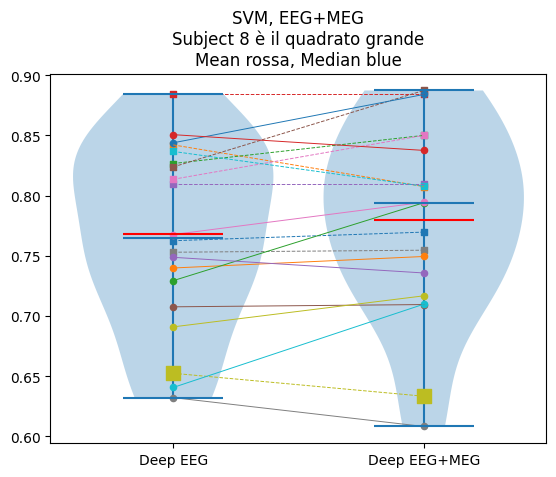

In [14]:
fig, ax = plt.subplots()
perfs = acc_mean_handextracted_5s + acc_mean_deep_5s
xlabs = ["HandExtraced\n5s", "DeepExtraced\n5s"]

perfs = acc_mean_deep_1s + acc_mean_deep_5s
xlabs = ["DeepExtraced\n1s", "DeepExtraced\n5s"]

perfs = acc_mean_deep_1s + acc_mean_deep_region_selection_from_3s
xlabs = ["DeepExtraced\nselection from 1s", "DeepExtraced\nselection from 3s (on feedback)"]

perfs = acc_mean_handextracted_1s_region_selection_from_3s + acc_mean_deep_region_selection_from_3s
xlabs = ["HandExtractedPower1s_windows\n (region selection from 3s)", "DeepExtraced1s_windows\nselection from 3s (on feedback)"]

perfs = acc_mean_deep_important_regions + acc_mean_deep_region_selection_from_3s
xlabs = ["Deep Important Regions", "Deep Region Selection from 3s (on feedback)"]

perfs = acc_mean_deep_all_regions + acc_mean_deep_region_selection_from_3s
xlabs = ["Deep All 68 Regions", "Deep Region Selection from 3s\n(on feedback)"]

perfs = acc_mean_deep_EEG + acc_mean_deep_region_selection_from_3s
xlabs = ["Deep EEG", "Deep EEG+MEG"]

# perfs= acc_deep_EEG_important_regions + acc_deep_EEG_Only_EEG_selected_regions
# perfs = acc_mean_deep_MEG + acc_mean_deep_region_selection_from_3s
# xlabs = ["Deep MEG", "Deep EEG+MEG"]


for s in range(20):
    #print(s, (perfs[s] - perfs[s+20])*100)
    ax.scatter([1,2], [perfs[s], perfs[s+20]],
               s=100 if s==8 else 20,
               marker=["s","o"][s//10],
               color=f"C{s}")
    ax.plot([1,2], [perfs[s], perfs[s+20]],
            ls=["--","solid"][s//10], lw=0.7, color=f"C{s}")

viol = ax.violinplot([perfs[0:20], perfs[20:40]],
                     positions=[1,2], showmeans=True, showmedians=True, widths=0.8)
viol["cmeans"].set_color("red")
for p in viol["bodies"] + [viol["cbars"]]:
    p.set_zorder(-20)

ax.set_title("SVM, EEG+MEG\nSubject 8 è il quadrato grande\nMean rossa, Median blue")
ax.set_xticks([1,2], xlabs)


 mean MEG:0.69 mean EEG:0.77 mean EEG+MEG:0.78
 median MEG:0.68 median EEG:0.77 median EEG+MEG:0.79


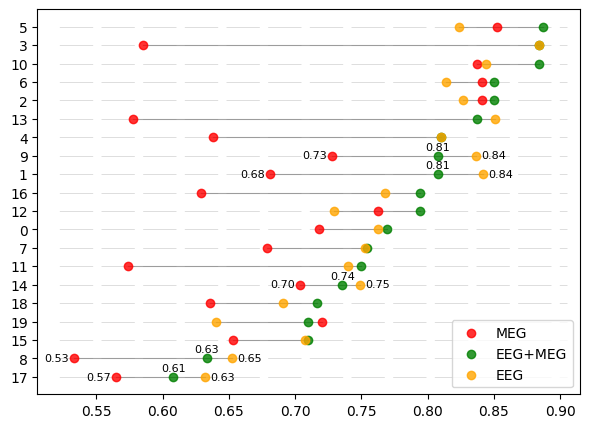

In [ ]:
EEG_better_fusion = [9,1,14,8,17]
fusion_better_EEG = [5,10,6,12,19]

lolliplot(acc_mean_deep_MEG,acc_mean_deep_region_selection_from_3s, 
          me=acc_mean_deep_EEG,annotate= EEG_better_fusion, legendlabels=["MEG", "EEG+MEG", "EEG"])

print(f" mean MEG:{np.mean(acc_mean_deep_MEG):.2f}", f"mean EEG:{np.mean(acc_mean_deep_EEG):.2f}", 
      f"mean EEG+MEG:{np.mean(acc_mean_deep_region_selection_from_3s):.2f}",  )
print(f" median MEG:{np.median(acc_mean_deep_MEG):.2f}", f"median EEG:{np.median(acc_mean_deep_EEG):.2f}", 
      f"median EEG+MEG:{np.median(acc_mean_deep_region_selection_from_3s):.2f}",  )

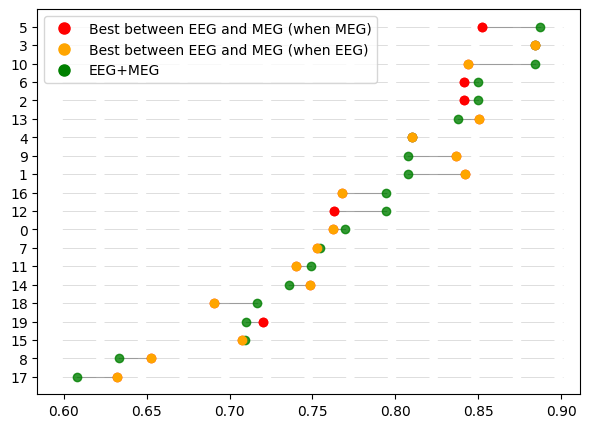

In [22]:
import matplotlib.lines as mlines

acc_mean_best_between_EEG_MEG = np.maximum(acc_mean_deep_EEG, acc_mean_deep_MEG)

fig,ax = lolliplot(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s)

ordine_EEEGplusMEG = np.argsort(acc_mean_deep_region_selection_from_3s)

best_MEG = []
best_EEG = []
for i in range(len(acc_mean_deep_MEG)):
    if acc_mean_deep_MEG[i] > acc_mean_deep_EEG[i]:
        best_MEG.append((acc_mean_deep_MEG[i],np.where(ordine_EEEGplusMEG==i)[0][0]))

for i in range(len(acc_mean_deep_EEG)):
    if acc_mean_deep_EEG[i] >= acc_mean_deep_MEG[i]:
        best_EEG.append((acc_mean_deep_EEG[i],np.where(ordine_EEEGplusMEG==i)[0][0]))

plt.scatter([i[0] for i in best_EEG], [i[1] for i in best_EEG], zorder=20,color="orange")
plt.scatter([i[0] for i in best_MEG], [i[1] for i in best_MEG], zorder=20,color="red")

red_dot = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                        markersize=8, label='Best between EEG and MEG (when MEG)')
orange_dot = mlines.Line2D([], [], color='orange', marker='o', linestyle='None',
                        markersize=8, label='Best between EEG and MEG (when EEG)'
                        )
green_dot = mlines.Line2D([], [], color='green', marker='o', linestyle='None',
                        markersize=8, label='EEG+MEG'
                        )
ax.legend(handles=[red_dot, orange_dot, green_dot])

    

### Test statistici - verifica differenze significative tra diversi addestramenti

In [ ]:
from scipy import stats
import numpy as np
stat, p_value = stats.wilcoxon(acc_mean_deep_MEG, acc_mean_deep_EEG, alternative="two-sided", zero_method="wilcox")
print(f"Test MEG different from EEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.wilcoxon(acc_mean_deep_MEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.wilcoxon(acc_mean_deep_EEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

acc_mean_best_between_EEG_MEG = np.maximum(acc_mean_deep_EEG, acc_mean_deep_MEG)

stat, p_value = stats.wilcoxon(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test best between EEG and MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")





Test MEG different from EEG: stat=26.0000, p=0.0020
Test MEG different from EEG+MEG: stat=3.0000, p=0.0000
Test EEG different from EEG+MEG: stat=52.0000, p=0.1446
Test best between EEG and MEG different from EEG+MEG: stat=75.0000, p=0.6475


In [ ]:
# Shapiro-Wilk - verifico se è possibile fare t-test o meno
# null hypotesis gaussian distribution
acc_mean_deep_MEG = np.array(acc_mean_deep_MEG)
acc_mean_deep_EEG = np.array(acc_mean_deep_EEG)
acc_mean_deep_region_selection_from_3s = np.array(acc_mean_deep_region_selection_from_3s)

stat, p_value = stats.shapiro(acc_mean_deep_MEG - acc_mean_deep_EEG)
print(f"Test MEG different from EEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.shapiro(acc_mean_deep_MEG- acc_mean_deep_region_selection_from_3s)
print(f"Test MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.shapiro(acc_mean_deep_EEG- acc_mean_deep_region_selection_from_3s)
print(f"Test EEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

acc_mean_best_between_EEG_MEG = np.maximum(acc_mean_deep_EEG, acc_mean_deep_MEG)

stat, p_value = stats.shapiro(acc_mean_best_between_EEG_MEG- acc_mean_deep_region_selection_from_3s)
print(f"Test best between EEG and MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

Test MEG different from EEG: stat=0.9549, p=0.4484
Test MEG different from EEG+MEG: stat=0.8824, p=0.0195
Test EEG different from EEG+MEG: stat=0.9455, p=0.3034
Test best between EEG and MEG different from EEG+MEG: stat=0.9661, p=0.6713


# Giustifica che scegliamo 8 regioni: Performance Vs number of region selected (EEG+MEG)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

nomebase = "../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_"
frm = "from_3s"
nregions = [4, 8, 12, 16, 20, 32, 68]
suffix = [f"_{u}regions.pkl" for u in nregions]
suffix[1] = ".pkl"


tutte_performance_dataframes = [nomebase + frm + s for s in suffix]
tutte_performance_dataframes[-1] = nomebase + "all_regions.pkl"

tutte_performance = []
for pat in tutte_performance_dataframes:
    # performance of each subject of each case
    tutte_performance.append(list(pd.read_pickle(pat).Accuracy.apply(np.mean).values))

tutte_performance = np.array(tutte_performance)

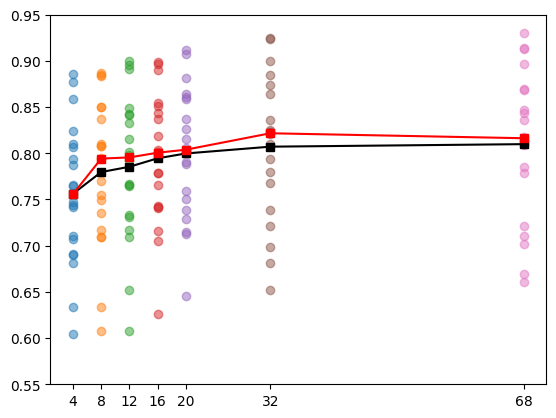

In [ ]:

plt.plot(nregions, tutte_performance.mean(axis=1), marker = "s", color="black", label="Mean")
plt.plot(nregions, np.median(tutte_performance,axis=1), marker = "s", color="red", label="Median")
plt.ylim((0.55,0.95))
plt.xticks(nregions)
for i in range(len(nregions)):
    plt.scatter([nregions[i] for _ in range(len(tutte_performance[i]))], tutte_performance[i], zorder=-1, alpha =0.5)

In [ ]:
for i in np.diff(tutte_performance.mean(axis=1)):
    print(f"{i:.3f}")

0.023
0.006
0.009
0.005
0.007
0.003


In [ ]:
tutte_performance.mean(axis=1)

array([0.75623298, 0.77967653, 0.78539054, 0.79452957, 0.79978925,
       0.80715118, 0.80988114])

### Test statistici - verifica differenze significative tra diversi addestramenti

Shapiro-Wilk uno tra i più usati per fare test di normalità di distribuzioni

In [ ]:
from scipy import stats
# Shapiro-Wilk - verifico se è possibile fare t-test o meno
# sembra conveniente non fare t-test (non c'è gaussianità)

for i in range(len(tutte_performance)):
    for j in range(i+1, len(tutte_performance)):
        differences = tutte_performance[i] - tutte_performance[j]  
        shapiro_stat, shapiro_p = stats.shapiro(differences)
        print(f"Shapiro-Wilk (test for normality) {i}, {j}: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print("Test normalità singole distribuzioni:")
for i in range(len(tutte_performance)):
    shapiro_stat, shapiro_p = stats.shapiro(tutte_performance[i])
    print(f"Shapiro-Wilk (test for normality) {i}, stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

Shapiro-Wilk (test for normality) 0, 1: stat=0.7239, p=0.0001
Shapiro-Wilk (test for normality) 0, 2: stat=0.7401, p=0.0001
Shapiro-Wilk (test for normality) 0, 3: stat=0.7605, p=0.0002
Shapiro-Wilk (test for normality) 0, 4: stat=0.8233, p=0.0020
Shapiro-Wilk (test for normality) 0, 5: stat=0.8741, p=0.0139
Shapiro-Wilk (test for normality) 0, 6: stat=0.9320, p=0.1688
Shapiro-Wilk (test for normality) 1, 2: stat=0.9369, p=0.2095
Shapiro-Wilk (test for normality) 1, 3: stat=0.8554, p=0.0066
Shapiro-Wilk (test for normality) 1, 4: stat=0.9367, p=0.2073
Shapiro-Wilk (test for normality) 1, 5: stat=0.9883, p=0.9951
Shapiro-Wilk (test for normality) 1, 6: stat=0.9708, p=0.7709
Shapiro-Wilk (test for normality) 2, 3: stat=0.7977, p=0.0008
Shapiro-Wilk (test for normality) 2, 4: stat=0.9480, p=0.3384
Shapiro-Wilk (test for normality) 2, 5: stat=0.9790, p=0.9201
Shapiro-Wilk (test for normality) 2, 6: stat=0.9944, p=1.0000
Shapiro-Wilk (test for normality) 3, 4: stat=0.9587, p=0.5191
Shapiro-

In [ ]:
# The Wilcoxon signed-rank test is a non-parametric alternative to the paired t-test.
# testo se esiste differenza nelle coppie (nreg,nreg+1)
for i in range(len(tutte_performance[:-1])):
    stat, p_value = stats.wilcoxon(tutte_performance[i], tutte_performance[i+1], alternative="two-sided", zero_method="wilcox")
    print(f"Wilcoxon signed-rank test: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.wilcoxon([0 ]*5, [25]*5, alternative="two-sided", zero_method="wilcox")
print(f"\n Wilcoxon signed-rank test: stat={stat:.4f}, p={p_value:.4f}")

Wilcoxon signed-rank test: stat=32.0000, p=0.0112
Wilcoxon signed-rank test: stat=57.0000, p=0.0759
Wilcoxon signed-rank test: stat=16.0000, p=0.0003
Wilcoxon signed-rank test: stat=47.5000, p=0.0318
Wilcoxon signed-rank test: stat=59.0000, p=0.0897
Wilcoxon signed-rank test: stat=76.5000, p=0.4565

 Wilcoxon signed-rank test: stat=0.0000, p=0.0625


# Region Selection
Maybe use Matlab (come trovo il DK atlas)?? IDK 
altrimenti vedi se riesci a fare un altra visualizzaizone (fatti aiutare da Claude)

In [4]:
import pandas as pd

pd.read_pickle("../Results/RegionSelection/Selected_regions_Cohen_effect_size_EEG_among_5_folds_training_selected_freq_8_30_starting_From_3s.pkl")

,Subject,ROIs_fold_1,Effect_size_fold_1,ROIs_fold_2,Effect_size_fold_2,ROIs_fold_3,Effect_size_fold_3,ROIs_fold_4,Effect_size_fold_4,ROIs_fold_5,Effect_size_fold_5,ROIs_All_trials,Effect_size_All_trials
0,0,"(32, 45, 48, 59, 33, 49, 51, 46, 44, 63, 23, 1...","(1.369846226584929, 1.2127215306071768, 1.1680...","(32, 45, 48, 44, 49, 33, 46, 27, 23, 15, 51, 4...","(1.304417396860337, 1.0848651843380064, 1.0833...","(45, 32, 49, 33, 51, 46, 44, 59, 63, 48, 23, 4...","(1.3349776236698092, 1.2643136202329166, 1.224...","(32, 45, 44, 49, 48, 46, 63, 23, 33, 17, 35, 1...","(1.247257642910836, 1.246226863560037, 1.08305...","(33, 32, 45, 49, 48, 44, 14, 59, 63, 51, 15, 4...","(1.2039749672250473, 1.2020655091445962, 1.193...","(32, 45, 49, 33, 48, 44, 46, 51, 63, 59, 23, 1...","(1.253510135459978, 1.2102929032293388, 1.1216..."
1,1,"(43, 59, 23, 7, 67, 61, 20, 27, 1, 32, 51, 26,...","(1.0890605787893894, 0.894907351449597, 0.8925...","(1, 43, 67, 61, 31, 23, 59, 7, 19, 51, 17, 42,...","(1.140401112276184, 0.9791818273332868, 0.9481...","(43, 59, 7, 67, 61, 23, 1, 51, 31, 42, 19, 26,...","(1.0836182733873398, 0.9492763650510093, 0.908...","(59, 43, 23, 1, 67, 61, 7, 51, 15, 31, 30, 20,...","(0.990597826369673, 0.9779673519056906, 0.9268...","(23, 7, 43, 59, 67, 61, 31, 51, 1, 30, 0, 42, ...","(1.067942226132348, 1.008709583679827, 1.00340...","(43, 59, 23, 67, 7, 61, 1, 31, 51, 42, 30, 19,...","(1.0249219621075485, 0.9421833106129563, 0.930..."
2,2,"(50, 32, 14, 44, 33, 4, 48, 47, 58, 62, 46, 59...","(1.8745863484229222, 1.8291022394462828, 1.693...","(50, 14, 32, 33, 44, 4, 48, 47, 62, 58, 46, 45...","(1.9785416154965214, 1.821505720362925, 1.8138...","(32, 50, 14, 44, 33, 48, 58, 4, 47, 62, 46, 45...","(1.8465688110372507, 1.8214540663338978, 1.739...","(50, 32, 14, 44, 33, 48, 4, 47, 58, 62, 46, 45...","(1.8630847754563307, 1.8565010599224583, 1.756...","(32, 14, 50, 33, 44, 48, 4, 47, 46, 45, 62, 58...","(1.91496891213288, 1.764756796926345, 1.692196...","(50, 32, 14, 44, 33, 48, 4, 47, 58, 62, 46, 45...","(1.8377477107632003, 1.8307961786990699, 1.751..."
3,3,"(7, 22, 15, 51, 23, 56, 20, 48, 3, 66, 59, 41,...","(0.8759220729073511, 0.7444406268580183, 0.725...","(7, 41, 51, 48, 15, 62, 22, 0, 23, 59, 56, 52,...","(0.8808831916976507, 0.8467073409268726, 0.800...","(7, 15, 59, 22, 51, 41, 66, 48, 23, 43, 14, 3,...","(0.890855446137651, 0.8197591351186931, 0.8017...","(7, 22, 15, 51, 3, 48, 32, 56, 23, 41, 52, 54,...","(0.8071813147319408, 0.7973235594160016, 0.773...","(15, 22, 51, 7, 48, 56, 41, 23, 14, 43, 59, 8,...","(0.8498121673813349, 0.8162971792417202, 0.791...","(7, 15, 22, 51, 48, 41, 59, 56, 23, 3, 66, 43,...","(0.8197250998937979, 0.7917662881318532, 0.756..."
4,4,"(16, 30, 12, 34, 48, 26, 7, 0, 28, 42, 55, 62,...","(1.012168270840584, 0.9199638076185492, 0.8772...","(16, 30, 12, 34, 2, 48, 28, 26, 3, 31, 1, 11, ...","(1.0289331040137433, 0.9826860446027488, 0.950...","(16, 30, 12, 7, 26, 0, 34, 2, 28, 18, 55, 32, ...","(1.0890644789744954, 0.9406276043986482, 0.893...","(16, 30, 12, 26, 34, 48, 2, 3, 55, 28, 7, 46, ...","(1.0399759488129183, 1.0017471594757592, 0.925...","(16, 30, 12, 28, 8, 34, 2, 29, 26, 3, 53, 65, ...","(1.0277114731740942, 1.0132631960858751, 0.982...","(16, 30, 12, 34, 26, 28, 2, 3, 7, 29, 8, 48, 0...","(1.0125712731076575, 0.9720477161284052, 0.924..."
5,5,"(17, 20, 43, 4, 62, 23, 22, 42, 51, 12, 27, 15...","(1.5065700618886015, 1.4517743125163471, 1.385...","(20, 4, 43, 17, 12, 62, 23, 63, 22, 15, 58, 16...","(1.6050067146089784, 1.3791139378645236, 1.336...","(20, 4, 17, 62, 43, 23, 12, 22, 47, 51, 15, 42...","(1.5544949555997118, 1.4996417645699827, 1.397...","(20, 17, 4, 43, 62, 47, 23, 42, 22, 12, 15, 27...","(1.6512296542931342, 1.4288997306212972, 1.403...","(12, 20, 17, 27, 4, 43, 22, 15, 16, 6, 23, 62,...","(1.4870220831674381, 1.4816783249577496, 1.470...","(20, 17, 4, 43, 62, 12, 22, 23, 15, 27, 42, 51...","(1.5406327033166924, 1.4267943225253052, 1.350..."
6,6,"(44, 32, 48, 47, 4, 58, 

# Windowizing procedure - Oerlap schematization


2026-07-18 12:38:42.416150: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-18 12:38:42.471115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-18 12:38:43.638101: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))
subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))


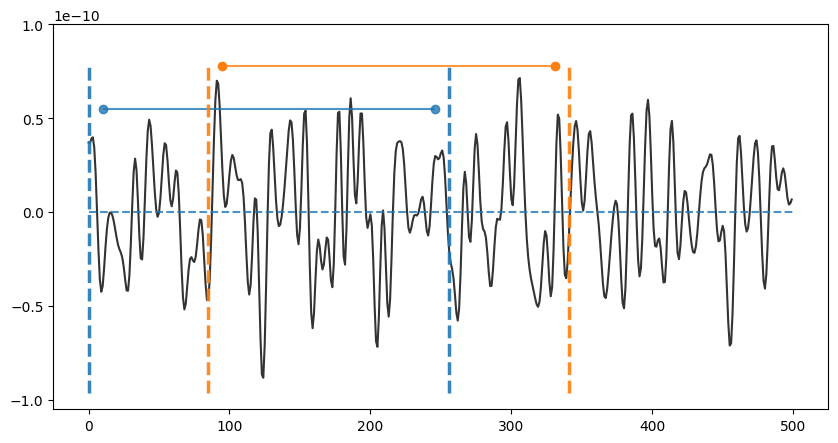

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import read_subject


data_folder="../Data/"


subject_index = 1

data_2_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_2_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250

from scipy.signal import firwin, filtfilt
figname="../Images/Windowing_example.png"

signal = data_2_MI[1][19]
numtaps = 501
fs = 250 
fir = firwin(numtaps, [4, 35], pass_zero=False, fs=fs)
filtered = filtfilt(fir, 1.0,signal )

shift = 200
amplitude_tot = 500 

T = 256
shift = 85
hline_shift = 10
hls = hline_shift

fg,ax =plt.subplots(figsize=(10,5))
ax.plot(filtered[shift:amplitude_tot+shift],color="black",alpha=0.8)
ymin,ymax = np.array(ax.get_ylim())#*1.1
plt.hlines(0,0,amplitude_tot,linestyles="--", alpha = 0.8)

plt.vlines([0,T],ymin,ymax , linestyles="--", alpha = 0.9, linewidth=2.5)
plt.hlines(0.55*10**(-10),hls ,T-hls, alpha = 0.8)
plt.scatter([hls ,T-hls],[0.55*10**(-10)]*2, alpha = 0.8)

plt.vlines([0+shift,T+shift],ymin,ymax, linestyles="--", alpha = 0.9, color = "C1" , linewidth=2.5,zorder=4)
plt.hlines([0.78*10**(-10)],hls+shift,T-hls+shift, alpha = 0.8,color="C1")
plt.scatter([hls+shift ,T-hls+shift],[0.78*10**(-10)]*2,zorder=3,color="C1")

ticks = plt.yticks(np.arange(-1,1.5,0.5)*10**(-10))
plt.savefig(figname, dpi=300, bbox_inches='tight')
# plt.vlines([0+2*shift,T+2*shift],ymin,ymax, linestyles="--", alpha = 0.9, color = "C2" , linewidth=2.5,zorder=4)
# plt.hlines([0.98*10**(-10)],hls+2*shift,T-hls+2*shift, alpha = 0.8,color="C2")
# plt.scatter([hls+2*shift ,T-hls+2*shift],[0.98*10**(-10)]*2,zorder=3,color="C2")